# 01 — Figure 1: teacher interface (giảm chiều + chọn toạ độ)

Notebook canonical cho hình teaser: teacher gốc, teacher đã giảm chiều với nhiều
realization toạ độ, target sau khi chọn toạ độ theo student, và phân bố cosine mà
`R` thật sự tối ưu.

**Hai tập câu, hai vai trò khác nhau.**

- *Fit set* — corpus train, mặc định `talas_15k`. `P_PCA` và `R` được fit trên đúng
  tập này, đúng như lúc train, nên số in ra ở cell 5 phải trùng log của run thật.
- *Plot set* — một split **có nhãn** (`emotion_test`, 6 lớp). Corpus distill không có
  nhãn, nên tô màu cụm trên nó sẽ phải bịa ra lớp bằng k-means. Dùng một split có
  nhãn sẵn thì mỗi màu là một lớp thật, và map thì vẫn là map của bài.

**Ba bảo đảm để hình là bằng chứng chứ không phải minh hoạ.**

- Mọi phép fit chạy ở `d_S` chiều gốc, bằng chính các hàm `src/teacher_projection.py`
  mà `distiller.py` gọi. 2D/3D chỉ là cách nhìn.
- Một khung nhìn duy nhất: `W_Z` fit một lần trên student pretrained rồi dùng chung
  cho `Y`, mọi `YQ` và `YR*`. PCA tự nó được phép xoay trục, nên fit riêng từng đám
  mây là tự tạo ra alignment.
- Panel (d) đo ở `d_S` chiều, không qua bước chiếu nào, trên toàn bộ fit set.

Cell 5 tự đối chiếu với log của run headline
(`runs/pca_384__selected/seed_42/train.log`: 92.8% năng lượng, cosine −0.013 → +0.654,
participation ratio 1.37). Lệch quá ngưỡng là fail.

**Caption phải nói**: hình vẽ `R` tại thời điểm khởi tạo; recipe mặc định
(`gauge_refit_every = 1`) refit `R` mỗi epoch.

In [1]:
# 1. Cấu hình hình
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"

PAIRS = {
    "qwen3_0.6b_to_minilm_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "teacher_pooling": "last_token",
        "student_pooling": "cls",
        "min_vram_gib": 12,
    },
    "bge_m3_to_minilm_h768": {
        "teacher": "BAAI/bge-m3",
        "student": "nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base",
        "teacher_pooling": "cls",
        "student_pooling": "cls",
        "min_vram_gib": 12,
    },
    "qwen3_4b_to_bert_base": {
        "teacher": "Qwen/Qwen3-Embedding-4B",
        "student": "google-bert/bert-base-uncased",
        "teacher_pooling": "last_token",
        "student_pooling": "cls",
        "min_vram_gib": 24,
    },
}
# Cặp headline: cùng cặp mà runs/pca_384__selected đã train.
PAIR = "qwen3_0.6b_to_minilm_h384"

SENTENCE_SOURCES = {
    "talas_15k": Path("data/train_set/merged_3_data_5k_each.csv"),
    "100k": Path("data/train_set/train_100k.csv"),
    "msmarco_15k_disjoint": Path("data/train_set/corpus_disjoint_msmarco_15k.csv"),
    "emotion_test": Path("data/test_set/emotion_test.csv"),
    "tweet_test": Path("data/test_set/tweet_test.csv"),
    "banking77_test": Path("data/test_set/banking77_test.csv"),
}
# Tập fit: corpus train, đúng tập P_PCA và R được fit lúc train.
FIT_SOURCE = "talas_15k"
# Tập vẽ: split có nhãn, nên mỗi màu là một lớp thật thay vì k-means bịa trên corpus.
PLOT_SOURCE = "emotion_test"
N_PLOT_LABELS = 6
N_PLOT_PER_LABEL = 85

MAX_LENGTH = 256
N_FIT = 0            # 0 = toàn bộ fit source
HAAR_SEED = 0        # trùng gauge_random_seed mặc định
N_HAAR_GHOSTS = 7    # số realization toạ độ mờ ở panel (b)
GHOST_SEED = 101     # tách khỏi HAAR_SEED: ghost là minh hoạ, Q ở panel (c)/(d) là control

# Khung nhìn 2D fit trên Z_0 chưa center: các vector nằm trên mặt cầu và loss là
# cosine, nên mean direction là hình học thật của student. Center trước khi fit sẽ
# ném đúng hướng mà R* xoay ra khỏi hình (participation ratio 1.37).
FRAME_CENTER = False

REFERENCE_RUN = "runs/pca_384__selected/seed_42/train.log"
REFERENCE_STATS = {
    "explained_energy": 0.928,
    "cos_before": -0.013,
    "cos_after": 0.654,
    "participation_ratio": 1.37,
    "samples": 14760,
}
REFERENCE_TOLERANCE = 0.02

FIGURE_STEM = "interface_geometry"
RUN_STAMP = datetime.now(ZoneInfo("Asia/Ho_Chi_Minh")).strftime("%Y%m%d-%H%M%S")

PAIR_CONFIG = PAIRS[PAIR]
TEACHER_MODEL = PAIR_CONFIG["teacher"]
STUDENT_MODEL = PAIR_CONFIG["student"]
TEACHER_POOLING = PAIR_CONFIG["teacher_pooling"]
STUDENT_POOLING = PAIR_CONFIG["student_pooling"]
FIT_PATH = SENTENCE_SOURCES[FIT_SOURCE]
PLOT_PATH = SENTENCE_SOURCES[PLOT_SOURCE]
IS_REFERENCE_CONFIG = (
    PAIR == "qwen3_0.6b_to_minilm_h384" and FIT_SOURCE == "talas_15k" and N_FIT == 0
)

print(f"Pair: {PAIR}")
print(f"Fit: {FIT_SOURCE} ({FIT_PATH})")
print(f"Plot: {PLOT_SOURCE} ({PLOT_PATH})")
print(f"Self-check với {REFERENCE_RUN}: {'bật' if IS_REFERENCE_CONFIG else 'tắt'}")

Pair: qwen3_0.6b_to_minilm_h384
Fit: talas_15k (data/train_set/merged_3_data_5k_each.csv)
Plot: emotion_test (data/test_set/emotion_test.csv)
Self-check với runs/pca_384__selected/seed_42/train.log: bật


In [2]:
# 2. Dùng repo hiện tại hoặc clone trên Colab; cài dependencies.
import subprocess
import sys

cwd = Path.cwd().resolve()
LOCAL_REPO = (cwd / "main.py").is_file() and (cwd / "distiller.py").is_file()
if LOCAL_REPO:
    PROJECT_DIR = cwd
else:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if PROJECT_DIR.exists():
        assert (PROJECT_DIR / "main.py").is_file(), f"Repo không hợp lệ: {PROJECT_DIR}"
    else:
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)

# Chỉ pull ở bản clone: checkout local là nơi bài đang được viết và thường có thay
# đổi chưa commit, --ff-only sẽ hoặc fail hoặc kéo mất trạng thái đang làm dở.
if not LOCAL_REPO:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(PROJECT_DIR / "requirements.txt")],
        check=True,
    )
head = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
print(f"Project: {PROJECT_DIR} @ {head}")

Project: /content/embedding-kd @ 663aedd


In [3]:
# 3. Output, device, và hai tập câu
import os

import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(PROJECT_DIR))

FIGURE_DIR = PROJECT_DIR / "docs" / "latex_iclr" / "figures"
EMBEDDING_CACHE_DIR = PROJECT_DIR / "runs" / "figure_cache"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"cuda:0: {props.name} ({props.total_memory / 2**30:.1f} GiB)")
    if props.total_memory / 2**30 < PAIR_CONFIG["min_vram_gib"]:
        print(f"[WARN] Nên có >= {PAIR_CONFIG['min_vram_gib']} GiB cho teacher này.")
else:
    print("[WARN] Không có GPU: forward teacher qua toàn bộ fit set trên CPU mất "
          "hàng giờ. Cell 4 cache lại nên chỉ phải trả giá một lần.")


def read_texts(relative_path):
    """Cột text của một file dữ liệu, theo đúng quy tắc của Distiller._cache_texts."""
    path = PROJECT_DIR / relative_path
    if not path.is_file():
        raise FileNotFoundError(f"Thiếu dữ liệu: {path}")
    frame = pd.read_csv(path)
    for column in ("premise", "sentence1", "text"):
        if column in frame.columns:
            return frame, column
    raise ValueError(f"Không tìm thấy cột text trong {path}: {list(frame.columns)}")


fit_frame, fit_column = read_texts(FIT_PATH)
FIT_TEXTS = fit_frame[fit_column].astype(str).tolist()
if N_FIT:
    FIT_TEXTS = FIT_TEXTS[:N_FIT]

plot_frame, plot_column = read_texts(PLOT_PATH)
label_column = next(
    (c for c in ("label_text", "label", "score") if c in plot_frame.columns), None
)
if label_column is None:
    raise ValueError(
        f"{PLOT_PATH} không có cột nhãn; hình tô màu theo lớp nên plot source phải "
        "là một split có nhãn"
    )
# Giữ N_PLOT_LABELS lớp lớn nhất và lấy cùng số câu mỗi lớp: một lớp 65 câu cạnh một
# lớp 688 câu sẽ đọc thành "cụm to/cụm nhỏ" trong khi đó chỉ là tần suất của split.
counts = plot_frame[label_column].astype(str).value_counts()
kept_labels = list(counts.index[:N_PLOT_LABELS])
rng = np.random.default_rng(0)
selected = []
for label in kept_labels:
    rows = plot_frame.index[plot_frame[label_column].astype(str) == label].to_numpy()
    take = min(N_PLOT_PER_LABEL, len(rows))
    selected.append(rng.choice(rows, size=take, replace=False))
selected = np.sort(np.concatenate(selected))
plot_subset = plot_frame.loc[selected]
PLOT_TEXTS = plot_subset[plot_column].astype(str).tolist()
PLOT_LABELS = plot_subset[label_column].astype(str).to_numpy()
LABEL_ORDER = kept_labels

print(f"Fit: {len(FIT_TEXTS):,} câu (cột '{fit_column}')")
print(f"Plot: {len(PLOT_TEXTS)} câu, {len(LABEL_ORDER)} lớp "
      f"({', '.join(LABEL_ORDER)}), cột nhãn '{label_column}'")
print(f"Figures: {FIGURE_DIR}")

cuda:0: NVIDIA A100-SXM4-40GB (39.5 GiB)
Fit: 14,760 câu (cột 'text')
Plot: 490 câu, 6 lớp (joy, sadness, anger, fear, love, surprise), cột nhãn 'label_text'
Figures: /content/embedding-kd/docs/latex_iclr/figures


In [4]:
# 4. Encode teacher và student pretrained (cache theo từng tập câu)
import hashlib

import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

from src.structural_audit import encode_texts

ENCODE_BATCH_SIZE = 64 if DEVICE == "cuda" else 8


def _load_model(name, dtype=None):
    """AutoModel.from_pretrained, chịu được cả tên keyword cũ lẫn mới của dtype.

    transformers >= 5 đổi ``torch_dtype`` thành ``dtype``; distiller.py xử lý chuyện
    này ở chỗ khác, notebook thì phải tự chịu vì Colab pin phiên bản riêng.
    """
    kwargs = {"trust_remote_code": True}
    if dtype is None:
        return AutoModel.from_pretrained(name, **kwargs)
    try:
        return AutoModel.from_pretrained(name, dtype=dtype, **kwargs)
    except TypeError:
        return AutoModel.from_pretrained(name, torch_dtype=dtype, **kwargs)


def _encode(model, tokenizer, texts, pooling):
    # no_grad chứ không phải inference_mode: encode_texts cấp phát buffer kết quả
    # *bên trong* context, và một inference tensor thì không đem đi save hay đưa vào
    # các op sau này được (xem ghi chú cùng chuyện đó trong src/cache_teacher.py).
    with torch.no_grad():
        pooled = encode_texts(
            model, tokenizer, texts, device=DEVICE, pooling=pooling,
            batch_size=ENCODE_BATCH_SIZE, max_length=MAX_LENGTH,
            amp=DEVICE == "cuda", progress=True,
        )["final"]
    # normalize: teacher cache lúc train có normalize_cache=True và
    # Distiller._student_initial_embeddings cũng normalize, nên hai ma trận ở đây
    # đúng bằng hai ma trận mà P_PCA và R được fit trên.
    return F.normalize(pooled.float(), dim=-1).clone()


# Cache tách theo từng tập câu, không gộp: đổi PLOT_SOURCE là chuyện thường, và không
# có lý do gì để nó bắt encode lại 14.760 câu của fit set.
def cache_entry(source_name, texts):
    identity = "|".join([
        TEACHER_MODEL, STUDENT_MODEL, TEACHER_POOLING, STUDENT_POOLING,
        str(MAX_LENGTH), str(len(texts)),
        hashlib.sha256("\n".join(texts).encode("utf-8")).hexdigest()[:16],
    ])
    digest = hashlib.sha256(identity.encode()).hexdigest()[:12]
    return identity, EMBEDDING_CACHE_DIR / f"{PAIR}__{source_name}__{digest}.pt"


# Khoá theo vai trò ("fit"/"plot") chứ không theo tên source: plot set là một *tập
# con* có nhãn, nên ngay cả khi hai vai trò cùng đọc một file dữ liệu thì chúng vẫn
# là hai danh sách câu khác nhau.
ROLES = {"fit": (FIT_SOURCE, FIT_TEXTS), "plot": (PLOT_SOURCE, PLOT_TEXTS)}

embeddings = {}
pending = {}
for role, (name, texts) in ROLES.items():
    identity, path = cache_entry(name, texts)
    if path.is_file():
        payload = torch.load(path, map_location="cpu", weights_only=False)
        assert payload["identity"] == identity, f"Cache không khớp cấu hình: {path}"
        embeddings[role] = payload
        print(f"Đọc lại embeddings đã cache: {path}")
    else:
        pending[role] = (texts, identity, path)

if pending:
    print(f"Encoding teacher {TEACHER_MODEL} ...")
    teacher_tokenizer = AutoTokenizer.from_pretrained(
        TEACHER_MODEL, trust_remote_code=True, use_fast=True
    )
    teacher_model = _load_model(TEACHER_MODEL, torch.bfloat16 if DEVICE == "cuda" else None)
    teacher_model.eval().to(DEVICE)
    teacher_side = {
        role: _encode(teacher_model, teacher_tokenizer, texts, TEACHER_POOLING)
        for role, (texts, _, _) in pending.items()
    }
    del teacher_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # Student *trước* distill: đúng ma trận Procrustes fit vào.
    print(f"Encoding student {STUDENT_MODEL} (pretrained, chưa distill) ...")
    student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL, use_fast=True)
    student_model = _load_model(STUDENT_MODEL)
    student_model.eval().to(DEVICE)
    student_side = {
        role: _encode(student_model, student_tokenizer, texts, STUDENT_POOLING)
        for role, (texts, _, _) in pending.items()
    }
    del student_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    for role, (texts, identity, path) in pending.items():
        payload = {
            "teacher": teacher_side[role], "student": student_side[role],
            "identity": identity, "pair": PAIR, "source": ROLES[role][0],
            "role": role, "texts": len(texts),
            "teacher_model": TEACHER_MODEL, "student_model": STUDENT_MODEL,
            "teacher_pooling": TEACHER_POOLING, "student_pooling": STUDENT_POOLING,
            "max_length": MAX_LENGTH, "stamp": RUN_STAMP,
        }
        torch.save(payload, path)
        embeddings[role] = payload
        print(f"Đã ghi {path}")

T_FIT, Z_FIT = embeddings["fit"]["teacher"], embeddings["fit"]["student"]
T_PLOT, Z_PLOT = embeddings["plot"]["teacher"], embeddings["plot"]["student"]
D_T, D_S = T_FIT.shape[1], Z_FIT.shape[1]
print(f"fit  T {tuple(T_FIT.shape)}  Z {tuple(Z_FIT.shape)}")
print(f"plot T {tuple(T_PLOT.shape)}  Z {tuple(Z_PLOT.shape)}")

Đọc lại embeddings đã cache: /content/embedding-kd/runs/figure_cache/qwen3_0.6b_to_minilm_h384__talas_15k__1685e7d52e50.pt
Đọc lại embeddings đã cache: /content/embedding-kd/runs/figure_cache/qwen3_0.6b_to_minilm_h384__emotion_test__ef69dd5b8e3d.pt
fit  T (14760, 1024)  Z (14760, 384)
plot T (490, 1024)  Z (490, 384)


In [5]:
# 5. Fit P_PCA và gauge R ở d_S chiều gốc, bằng đúng các hàm distiller.py gọi
from src.teacher_projection import (
    fit_gauge_alignment,
    fit_pca_projection,
    project_teacher_embeddings,
    random_orthogonal,
    retained_energy,
)

RANK = min(D_S, D_T)
# center=True / subtract_mean=False là cấu hình của bài: mean được bỏ khi *chọn* hướng,
# nhưng map được apply đúng dạng tuyến tính P_T (geoode_config.py:106-109).
P_PCA, TEACHER_MEAN = fit_pca_projection(T_FIT, out_dim=RANK, center=True)
if RANK < D_S:
    P_PCA = F.pad(P_PCA, (0, D_S - RANK)).contiguous()


def reduce_teacher(matrix):
    return project_teacher_embeddings(
        matrix, P_PCA, mean=TEACHER_MEAN, subtract_mean=False
    )


Y_FIT = reduce_teacher(T_FIT)
R_STAR, GAUGE_STATS = fit_gauge_alignment(Y_FIT, Z_FIT)
Q_HAAR = random_orthogonal(D_S, seed=HAAR_SEED)
ENERGY = retained_energy(T_FIT, P_PCA)

# Cosine từng câu ở d_S chiều trên toàn bộ fit set: đại lượng R* thật sự tối ưu, và
# là con số duy nhất trong hình không đi qua một phép chiếu nào.
COSINES = {
    "PCA only": (Y_FIT * Z_FIT).sum(-1).numpy(),
    "PCA + Haar $Q$": (F.normalize(Y_FIT @ Q_HAAR, dim=-1) * Z_FIT).sum(-1).numpy(),
    r"PCA + Procrustes $R^{\star}$": (F.normalize(Y_FIT @ R_STAR, dim=-1) * Z_FIT).sum(-1).numpy(),
}

# Cùng ba map đó, áp lên tập có nhãn để vẽ. Không fit lại gì cả.
Y_PLOT = reduce_teacher(T_PLOT)
Y_PLOT_ROT = F.normalize(Y_PLOT @ R_STAR, dim=-1)
GHOST_ROTATIONS = [
    F.normalize(Y_PLOT @ random_orthogonal(D_S, seed=GHOST_SEED + index), dim=-1)
    for index in range(N_HAAR_GHOSTS)
]

print(f"rank-{RANK} PCA {D_T} -> {D_S}: giữ {ENERGY:.1%} năng lượng "
      f"(subspace ngẫu nhiên cùng hạng giữ ~{RANK / D_T:.1%})")
print(f"gauge trên {GAUGE_STATS['samples']:,} câu: cosine "
      f"{GAUGE_STATS['cos_before']:+.3f} -> {GAUGE_STATS['cos_after']:+.3f}")
print(f"participation ratio {GAUGE_STATS['participation_ratio']:.2f} / {D_S} "
      f"(top singular share {GAUGE_STATS['top_singular_share']:.3f})")
print(f"Haar control: cosine {COSINES['PCA + Haar $Q$'].mean():+.3f}")

if IS_REFERENCE_CONFIG:
    # Hình phải mô tả đúng thí nghiệm trong bảng. Fit ở đây độc lập với run train, nên
    # nếu nó không tái tạo được log thì một trong hai chỗ sai -- và thà biết ngay còn
    # hơn để hình đẹp mà nói chuyện khác.
    observed = {
        "explained_energy": float(ENERGY),
        "cos_before": GAUGE_STATS["cos_before"],
        "cos_after": GAUGE_STATS["cos_after"],
        "participation_ratio": GAUGE_STATS["participation_ratio"],
        "samples": GAUGE_STATS["samples"],
    }
    drift = {
        key: (observed[key], REFERENCE_STATS[key])
        for key in REFERENCE_STATS
        if abs(observed[key] - REFERENCE_STATS[key])
        > (0 if key == "samples" else REFERENCE_TOLERANCE)
    }
    assert not drift, f"Lệch so với {REFERENCE_RUN}: {drift}"
    print(f"Self-check: khớp {REFERENCE_RUN} trong sai số {REFERENCE_TOLERANCE}")

rank-384 PCA 1024 -> 384: giữ 92.8% năng lượng (subspace ngẫu nhiên cùng hạng giữ ~37.5%)
gauge trên 14,760 câu: cosine -0.001 -> +0.654
participation ratio 1.37 / 384 (top singular share 0.855)
Haar control: cosine -0.003
Self-check: khớp runs/pca_384__selected/seed_42/train.log trong sai số 0.02


In [6]:
# 6. Khung nhìn. Fit một lần trên fit set, dùng chung -- fit riêng từng đám mây là
# tự tạo alignment.
def viewing_frame(matrix, dims=2, center=FRAME_CENTER):
    """``dims`` hướng chính của ``matrix``, kèm gốc toạ độ, dấu đã cố định.

    Trả ``(mu, W)`` để mọi đám mây được nhìn qua đúng một affine map
    ``x -> (x - mu) W``. Dấu mỗi cột do LAPACK chọn tuỳ ý, nên hình sẽ lật ngẫu nhiên
    giữa các lần chạy nếu không ép: quy ước ở đây là thành phần có trị tuyệt đối lớn
    nhất của mỗi cột phải dương.
    """
    mu = matrix.mean(dim=0) if center else torch.zeros(matrix.shape[1])
    _, _, vh = torch.linalg.svd(matrix - mu, full_matrices=False)
    basis = vh[:dims].transpose(0, 1).contiguous()
    signs = torch.sign(basis[basis.abs().argmax(dim=0), torch.arange(dims)])
    return mu, basis * torch.where(signs == 0, torch.ones_like(signs), signs)


def project(matrix, frame):
    mu, basis = frame
    return ((matrix - mu) @ basis).numpy()


# Panel (a) chỉ có duy nhất một đám mây nên khung của nó không so sánh gì với ai:
# fit trên chính các câu được vẽ để cấu trúc lớp hiện ra. Khung student thì ngược lại,
# phải là *một* khung dùng chung cho (b) và (c), và nó được đọc từ hình học của
# student trên corpus chứ không phải từ tập được vẽ.
TEACHER_FRAME = viewing_frame(T_PLOT, dims=3)
STUDENT_FRAME = viewing_frame(Z_FIT, dims=2)

VIEW = {
    "T": project(T_PLOT, TEACHER_FRAME),
    "Z": project(Z_PLOT, STUDENT_FRAME),
    "Y": project(Y_PLOT, STUDENT_FRAME),
    "YR": project(Y_PLOT_ROT, STUDENT_FRAME),
    "ghosts": [project(ghost, STUDENT_FRAME) for ghost in GHOST_ROTATIONS],
}

# Mỗi hàng là vector đơn vị ở d chiều nên bóng 2D của nó nằm trong đĩa bán kính 1;
# khung của panel thường nhỏ hơn thế nhiều, và con số đó đi vào sidecar để caption
# không nói quá về kích thước đám mây.
SPAN = {
    key: float(np.abs(value).max())
    for key, value in VIEW.items()
    if key != "ghosts"
}
SPAN["ghosts"] = float(max(np.abs(ghost).max() for ghost in VIEW["ghosts"]))
for key, value in SPAN.items():
    print(f"{key:7s}: |toạ độ| lớn nhất = {value:.3f} (bán kính mặt cầu = 1)")

T      : |toạ độ| lớn nhất = 0.822 (bán kính mặt cầu = 1)
Z      : |toạ độ| lớn nhất = 0.988 (bán kính mặt cầu = 1)
Y      : |toạ độ| lớn nhất = 0.167 (bán kính mặt cầu = 1)
YR     : |toạ độ| lớn nhất = 0.772 (bán kính mặt cầu = 1)
ghosts : |toạ độ| lớn nhất = 0.211 (bán kính mặt cầu = 1)


/tmp/ipykernel_8056/3978245277.py:6: RuntimeWarning: Đang dùng VIEW cũ qua key 'Y'. Cell 7 vẫn render được, nhưng hãy chạy lại cell 6 để dùng framing mới tối ưu cho paper.
  figure, FIGURE_PATHS = render_interface_geometry(


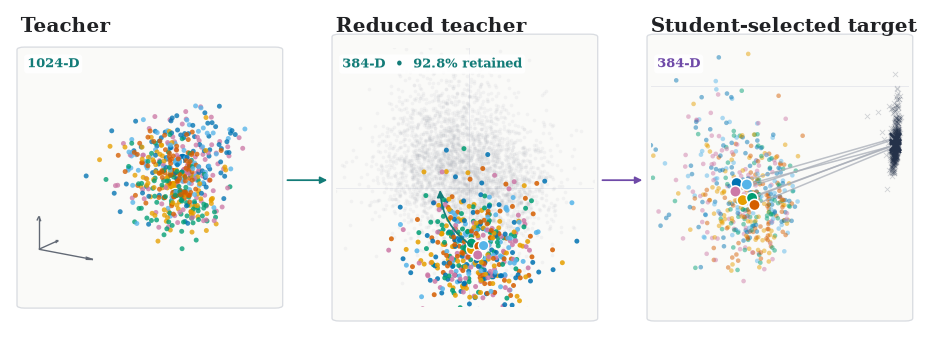

PDF: /content/embedding-kd/docs/latex_iclr/figures/interface_geometry.pdf
SVG: /content/embedding-kd/docs/latex_iclr/figures/interface_geometry.svg
PNG: /content/embedding-kd/docs/latex_iclr/figures/interface_geometry.png


In [7]:
# 7. Render một panel gồm ba hình ở đúng khổ ICLR. Logic hình nằm trong notebook;
# renderer chỉ sở hữu typography, layout, visual semantics và export. Hai hình 2D
# bắt buộc dùng cùng frame *và cùng window* để không tạo alignment giả.
from notebooks._interface_geometry_figure import render_interface_geometry

figure, FIGURE_PATHS = render_interface_geometry(
    view=VIEW,
    plot_labels=PLOT_LABELS,
    label_order=LABEL_ORDER,
    teacher_dim=D_T,
    student_dim=D_S,
    explained_energy=float(ENERGY),
    output_dir=FIGURE_DIR,
    stem=FIGURE_STEM,
    schematic=True,
)
pdf_path = FIGURE_PATHS["pdf"]
for format_name, path in FIGURE_PATHS.items():
    print(f"{format_name.upper():>3}: {path}")

In [8]:
# 8. Sidecar: mọi con số hình đang nói, để caption không phải chép tay
import json

sidecar = {
    "figure": FIGURE_STEM,
    "layout": "three-stage visual argument + quantitative ridgeline",
    "figure_size_inches": [5.5, 3.3],
    "exports": {name: str(path) for name, path in FIGURE_PATHS.items()},
    "generated": RUN_STAMP,
    "commit": head,
    "pair": PAIR,
    "teacher_model": TEACHER_MODEL,
    "student_model": STUDENT_MODEL,
    "teacher_pooling": TEACHER_POOLING,
    "student_pooling": STUDENT_POOLING,
    "fit_source": str(FIT_PATH),
    "fit_sentences": len(FIT_TEXTS),
    "plot_source": str(PLOT_PATH),
    "plot_sentences": len(PLOT_TEXTS),
    "plot_labels": LABEL_ORDER,
    "teacher_dim": D_T,
    "student_dim": D_S,
    "projection_rank": RANK,
    "explained_energy": float(ENERGY),
    "random_subspace_energy": RANK / D_T,
    "gauge": {key: float(value) for key, value in GAUGE_STATS.items()},
    "haar_seed": HAAR_SEED,
    "ghost_rotations": N_HAAR_GHOSTS,
    "mean_cosine": {label: float(values.mean()) for label, values in COSINES.items()},
    "frame_centered": bool(FRAME_CENTER),
    "coordinate_span": SPAN,
    "reference_run": REFERENCE_RUN if IS_REFERENCE_CONFIG else None,
    "gauge_refit_every_in_recipe": 1,
}
sidecar_path = FIGURE_DIR / f"{FIGURE_STEM}.json"
sidecar_path.write_text(json.dumps(sidecar, indent=2), encoding="utf-8")
print(f"Đã ghi {sidecar_path}")

# Câu về rank-one chỉ đúng khi PR thật sự nhỏ; để nó cứng trong caption là cách nhanh
# nhất để một lần đổi cặp teacher/student biến caption thành phát biểu sai.
gauge_shape = (
    "so the rotation is close to rank-one: it aligns one dominant direction"
    if GAUGE_STATS["participation_ratio"] < 0.05 * D_S
    else "so the rotation uses many directions, not a single dominant one"
)
print(f"""
\\caption{{\\textbf{{The teacher interface.}} {TEACHER_MODEL} $\\to$ {STUDENT_MODEL}.
(a) The teacher's own space, $d_T={D_T}$: too wide for the student, so a rank-${D_S}$
map is unavoidable. (b) $P_{{\\mathrm{{PCA}}}}$ fixes the subspace and keeps
{ENERGY:.1%} of the teacher's embedding energy, but leaves the coordinates free:
every $Q \\in O(d_S)$ gives the same Gram matrix and a different realization
(faded clouds). (c) $R^{{\\star}}$ picks the realization closest to the pretrained
student. (d) The quantity $R^{{\\star}}$ optimises, measured in
$\\mathbb{{R}}^{{{D_S}}}$ on all {GAUGE_STATS['samples']:,} fit sentences: mean cosine
{GAUGE_STATS['cos_before']:+.3f} $\\to$ {GAUGE_STATS['cos_after']:+.3f}, while a
Haar rotation of identical cost stays at
{COSINES['PCA + Haar $Q$'].mean():+.3f}. The cross-covariance has participation
ratio {GAUGE_STATS['participation_ratio']:.2f} of {D_S}, {gauge_shape}.
Colours in (a)--(c) are the {len(LABEL_ORDER)} classes of {PLOT_SOURCE}; the maps are
fitted on the training corpus and only applied to those sentences. All fits are
computed in the original {D_S}-dimensional student space; the plots show fixed
low-dimensional projections for visualisation only, and $R$ is shown at
initialisation (the recipe refits it each epoch).}}
""".strip())

Đã ghi /content/embedding-kd/docs/latex_iclr/figures/interface_geometry.json
\caption{\textbf{The teacher interface.} Qwen/Qwen3-Embedding-0.6B $\to$ nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base.
(a) The teacher's own space, $d_T=1024$: too wide for the student, so a rank-$384$
map is unavoidable. (b) $P_{\mathrm{PCA}}$ fixes the subspace and keeps
92.8% of the teacher's embedding energy, but leaves the coordinates free:
every $Q \in O(d_S)$ gives the same Gram matrix and a different realization
(faded clouds). (c) $R^{\star}$ picks the realization closest to the pretrained
student. (d) The quantity $R^{\star}$ optimises, measured in
$\mathbb{R}^{384}$ on all 14,760 fit sentences: mean cosine
-0.001 $\to$ +0.654, while a
Haar rotation of identical cost stays at
-0.003. The cross-covariance has participation
ratio 1.37 of 384, so the rotation is close to rank-one: it aligns one dominant direction.
Colours in (a)--(c) are the 6 classes of emotion_test; the maps are
fitted on the tr